<a href="https://colab.research.google.com/github/Matheus-Melo-dos-Santos/DIP-2026.2/blob/main/image_creator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ImageCreator: criação de imagens sintéticas

Este notebook apresenta imagens constantes, distribuições aleatórias e ruído sal-e-pimenta com resultados reproduzíveis. Todos os exemplos usam arrays NumPy e visualização com Matplotlib, sem arquivos externos.

## 1. Preparar o Google Colab

A instalação abaixo deve permanecer no notebook porque o ambiente do Colab é temporário.

In [ ]:
%pip install -q "git+https://github.com/tfvieira/dip-2026-2.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 15.4 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from dip_toolkit.modules.image_creator import ImageCreator

creator = ImageCreator(seed=2026)

## 2. Zeros, uns e valores constantes

O shape `(altura, largura)` representa uma imagem em escala de cinza. Um terceiro eixo, como em `(altura, largura, 3)`, representa canais.

Para dtypes inteiros, `create_ones_image` usa o valor máximo do dtype. Assim, uma imagem de uns em `uint8` contém `255` e é visualizada como branca. Para floats, o método usa `1.0`.

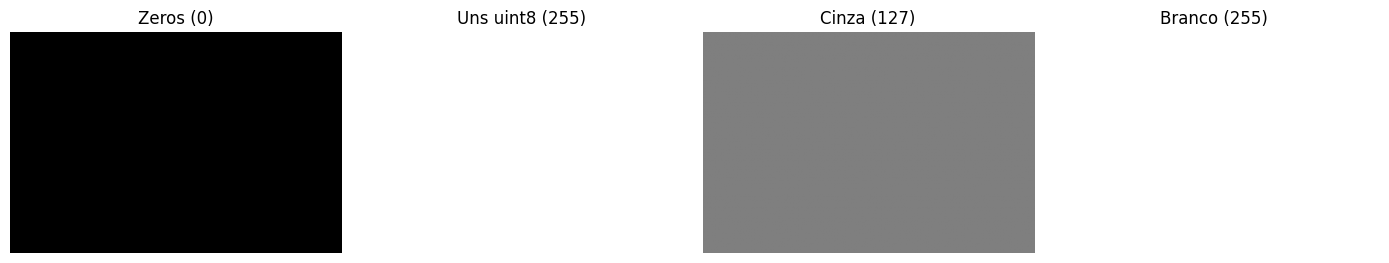

Shape da imagem branca: (80, 120)
Dtype da imagem branca: uint8


In [ ]:
zeros = creator.create_zeros_image((80, 120), dtype=np.uint8)
ones = creator.create_ones_image((80, 120), dtype=np.uint8)
middle_gray = creator.create_filled_image(
    (80, 120),
    value=127,
    dtype=np.uint8,
)
white = creator.create_filled_image(
    (80, 120),
    value=255,
    dtype=np.uint8,
)

images = [zeros, ones, middle_gray, white]
titles = ["Zeros (0)", "Uns uint8 (255)", "Cinza (127)", "Branco (255)"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for axis, image, title in zip(axes, images, titles, strict=True):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Shape da imagem branca:", white.shape)
print("Dtype da imagem branca:", white.dtype)

## 3. Imagens aleatórias reproduzíveis

O gerador criado com `seed=2026` avança a cada chamada. Para repetir exatamente uma imagem específica, também podemos informar uma seed diretamente ao método.

- Inteiros usam o domínio não negativo do dtype, como `[0, 255]` em `uint8`.
- Floats usam o domínio `[0.0, 1.0]`.
- Amostras normal e Rayleigh fora desse domínio são limitadas antes da conversão.

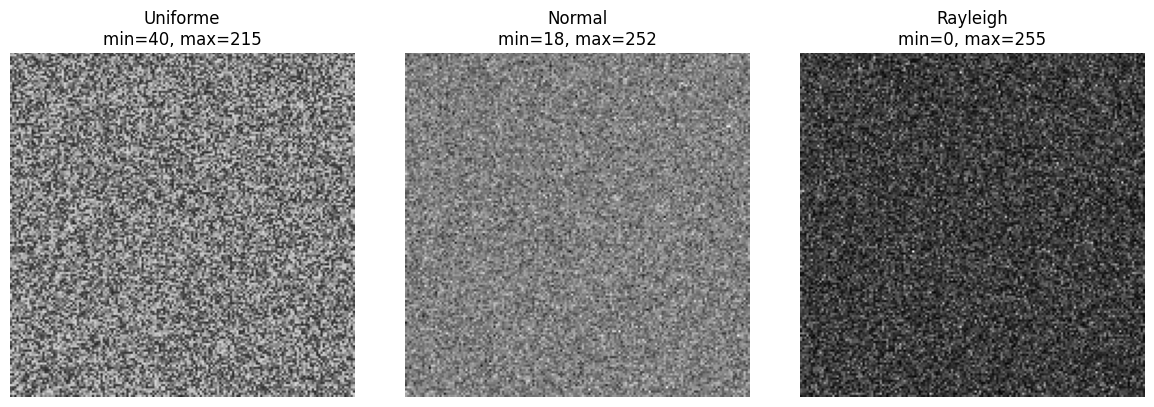

In [ ]:
uniform = creator.create_random_image(
    (160, 160),
    distribution="uniform",
    dtype=np.uint8,
    low=40,
    high=216,
    seed=10,
)
normal = creator.create_random_image(
    (160, 160),
    distribution="normal",
    dtype=np.uint8,
    mean=128,
    std=30,
    seed=10,
)
rayleigh = creator.create_random_image(
    (160, 160),
    distribution="rayleigh",
    dtype=np.uint8,
    scale=50,
    seed=10,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, image, title in zip(
    axes,
    [uniform, normal, rayleigh],
    ["Uniforme", "Normal", "Rayleigh"],
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"{title}\nmin={image.min()}, max={image.max()}")
    axis.axis("off")
plt.tight_layout()
plt.show()

Os histogramas ajudam a distinguir as distribuições numericamente, além da aparência das imagens.

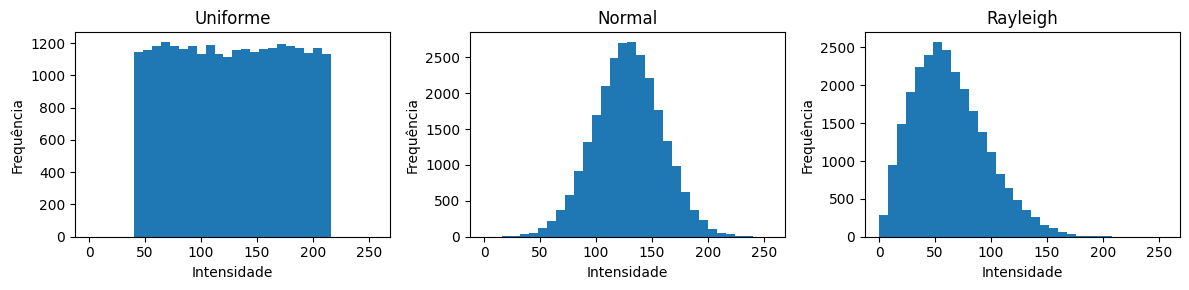

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for axis, image, title in zip(
    axes,
    [uniform, normal, rayleigh],
    ["Uniforme", "Normal", "Rayleigh"],
    strict=True,
):
    axis.hist(image.ravel(), bins=32, range=(0, 256))
    axis.set_title(title)
    axis.set_xlabel("Intensidade")
    axis.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

## 4. Dtypes de ponto flutuante e conversão

A imagem float abaixo permanece em `[0.0, 1.0]`. `change_image_dtype` sempre devolve um novo array. Na conversão float → inteiro, o NumPy trunca a parte fracionária; valores fora do intervalo do destino são rejeitados.

Float: float32 0.00025558085 0.99997425
Convertida: uint8 0 254
O array original foi preservado: True


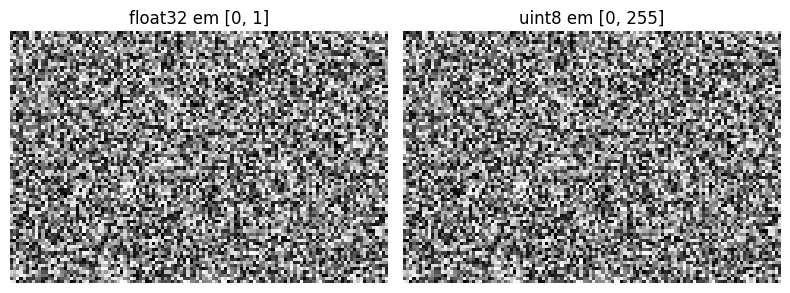

In [ ]:
float_image = creator.create_random_image(
    (80, 120),
    distribution="uniform",
    dtype=np.float32,
    seed=25,
)
quantized = creator.change_image_dtype(float_image * 255, np.uint8)

print("Float:", float_image.dtype, float_image.min(), float_image.max())
print("Convertida:", quantized.dtype, quantized.min(), quantized.max())
print("O array original foi preservado:", float_image.dtype == np.float32)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(float_image, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("float32 em [0, 1]")
axes[1].imshow(quantized, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("uint8 em [0, 255]")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 5. Ruído sal-e-pimenta

Cada pixel tem uma única classe: pimenta, sal ou fundo. Em float, esses níveis são `-1.0`, `1.0` e `0.5`, respectivamente. Para inteiros, pimenta vale `0`, o fundo vale `max(dtype) // 2` e sal vale `max(dtype)`. As probabilidades de sal e pimenta devem estar em `[0, 1]` e sua soma não pode ultrapassar `1`.

Níveis e quantidades: {np.float64(-1.0): np.int64(3453), np.float64(0.5): np.int64(36208), np.float64(1.0): np.int64(3539)}


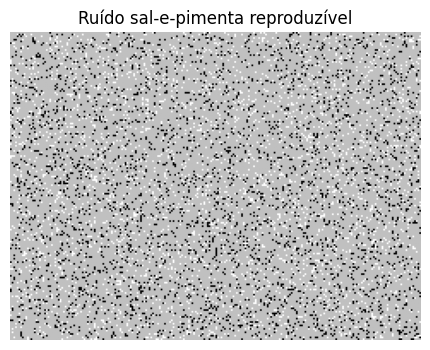

In [ ]:
noise = creator.create_salt_and_pepper_noise(
    height=180,
    width=240,
    salt_prob=0.08,
    pepper_prob=0.08,
    dtype=np.float64,
    seed=2026,
)

levels, counts = np.unique(noise, return_counts=True)
print("Níveis e quantidades:", dict(zip(levels, counts, strict=True)))

plt.figure(figsize=(7, 4))
plt.imshow(noise, cmap="gray", vmin=-1.0, vmax=1.0)
plt.title("Ruído sal-e-pimenta reproduzível")
plt.axis("off")
plt.show()

## 6. Exercício sugerido

1. Altere separadamente `salt_prob` e `pepper_prob`.
2. Conte quantos pixels pertencem a cada nível.
3. Aumente o tamanho da imagem e compare as frequências observadas com as probabilidades informadas.
4. Repita a chamada com a mesma seed e confirme que os arrays são idênticos com `np.array_equal`.

2 - Contagem de pixels do ruído 180x240
Níveis e quantidades: {np.float64(-1.0): np.int64(3453), np.float64(0.5): np.int64(36208), np.float64(1.0): np.int64(3539)}
---------------------------------------------------------------
3 - Contagem de frequencia da matriz aumentada 1000x1000
Nível: -1.0 - 80113 pixels, frequencia: 0.0801
Nível: 0.5 - 840375 pixels, frequencia: 0.8404
Nível: 1.0 - 79512 pixels, frequencia: 0.0795
---------------------------------------------------------------
Identical arrays?: True
DType noise float64 - DType new noisefloat64


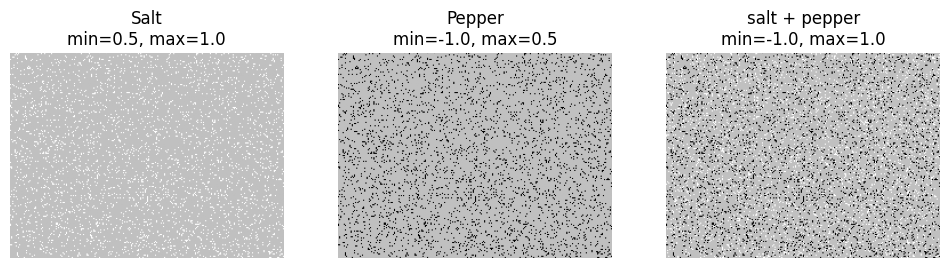

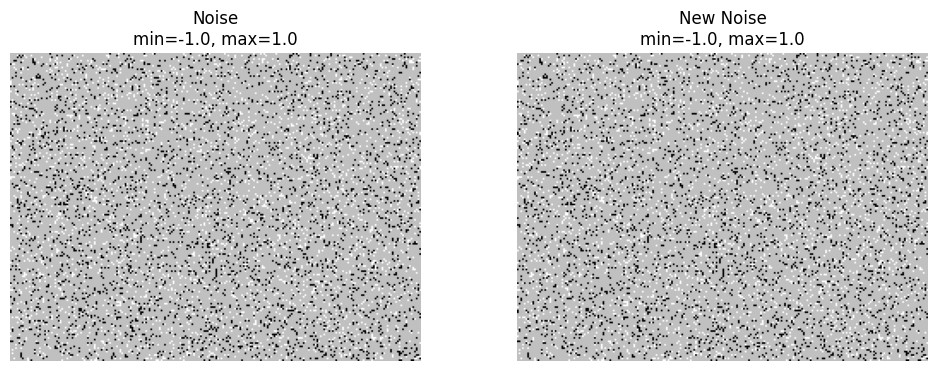

In [ ]:
# 1 - manipulação separa de salt_prob e pepper_prob

noise_salt_only = creator.create_salt_and_pepper_noise(
    height=180,
    width=240,
    salt_prob=0.08,
    pepper_prob=0.00,
    dtype=np.float64,
    seed=2026,
)

noise_pepper_only = creator.create_salt_and_pepper_noise(
    height=180,
    width=240,
    salt_prob=0.00,
    pepper_prob=0.08,
    dtype=np.float64,
    seed=2026,
)

noise = creator.create_salt_and_pepper_noise(
    height=180,
    width=240,
    salt_prob=0.08,
    pepper_prob=0.08,
    dtype=np.float64,
    seed=2026,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, image, title in zip(
    axes,
    [noise_salt_only,noise_pepper_only, noise],
    ["Salt", "Pepper", "salt + pepper"],
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=-1, vmax=1)
    axis.set_title(f"{title}\nmin={image.min()}, max={image.max()}")
    axis.axis("off")

# 2 - contar quantos pixels são de cada nível
levels, counts = np.unique(noise, return_counts=True)
print("2 - Contagem de pixels do ruído 180x240")
print("Níveis e quantidades:", dict(zip(levels, counts, strict=True)))
print("---------------------------------------------------------------")

# 3 - Aumentar imagem + contar frequencia e comparar com probabilidades

noise_1000_x_1000 = creator.create_salt_and_pepper_noise(
    height=1000,
    width=1000,
    salt_prob=0.08,
    pepper_prob=0.08,
    dtype=np.float64
)
print("3 - Contagem de frequencia da matriz aumentada 1000x1000")
levels, counts = np.unique(noise_1000_x_1000, return_counts=True)
for level, count in zip(levels, counts):
    print(f"Nível: {level} - {count} pixels, frequencia: {count/1000000:.4f}")
print("---------------------------------------------------------------")

new_noise = creator.create_salt_and_pepper_noise(
    height=180,
    width=240,
    salt_prob=0.08,
    pepper_prob=0.08,
    dtype=np.float64,
    seed=2026,
)

# 4 - Confirmando que os ruídos são iguas.
print("Identical arrays?:", np.array_equal(noise, new_noise))
print(f"DType noise {noise.dtype} - DType new noise: {new_noise.dtype}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, image, title in zip(
    axes,
    [noise, new_noise],
    ["Noise", "New Noise"],
    strict=True,
):
    axis.imshow(image, cmap="gray", vmin=-1, vmax=1)
    axis.set_title(f"{title}\nmin={image.min()}, max={image.max()}")
    axis.axis("off")

